In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

plt.style.use('ggplot')

In [2]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

# Gradient Descent
    It is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function. The idea is to take repeated steps in the opposite direction of the gradient (or approximate fradient) of the function at the current point, because this is the direction of steepest descent.

- **Types Of Gradient Descent**
  1) Batch Gradient Descent
  2) Stochastic Gradient Descent
  3) Mini Batch Gradient Descent

# Intuation
    Using 2D explanation and Single Linear Regression Loss Function for easier and better understanding

    Where, L = SumTotal(Yi - mXi - b)^2
        Therefor We can saysay that relation between L & b is 
            L -> b^2      (If "m" is constant in the equation)

In [3]:
def slope_points(x, y, length = 10):
    slope = 2*x
    b = y - (slope*x)
    X = np.arange(x - length, x + length)
    Y = slope*X + b
    return X,Y

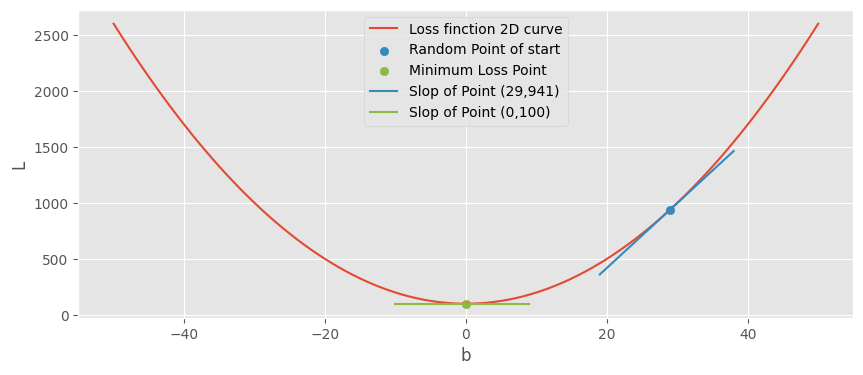

In [4]:
b = np.arange(-50, 51)
L = b**2 + 100

random_point_index = np.random.randint(0,b.shape[0],size=1)
plt.figure(figsize=(10,4))
plt.plot(b,L,color='C0', label='Loss finction 2D curve')
plt.scatter(x=b[random_point_index],y=L[random_point_index],
            color = 'C1', label='Random Point of start')
plt.scatter(x=b[int(b.shape[0]/2)],y=L[int(b.shape[0]/2)],
            color = 'C5', label='Minimum Loss Point')

x,y = slope_points(b[random_point_index][0],L[random_point_index][0])
plt.plot(x,y, color='C1', label=f'Slop of Point ({b[random_point_index][0]},{L[random_point_index][0]})')

x,y = slope_points(b[int(b.shape[0]/2)],L[int(b.shape[0]/2)])
plt.plot(x,y, color='C5', label=f'Slop of Point ({b[int(b.shape[0]/2)]},{L[int(b.shape[0]/2)]})')


plt.xlabel("b")
plt.ylabel("L")
plt.legend()
plt.show()

# Working Of Gradient Descent (Batch/Vanilla GD)
    Where Coef (m) is consents
    Gradient Descent is only applied in intercept (b)

In [5]:
def L_slope(X,y,m,b):
    return np.sum(y - (m*X) - b)*(-2)

In [6]:
X = np.arange(1,101).reshape(100,1)
delta = np.random.uniform(20,300,size=(100,1))
y = (5*X) + delta

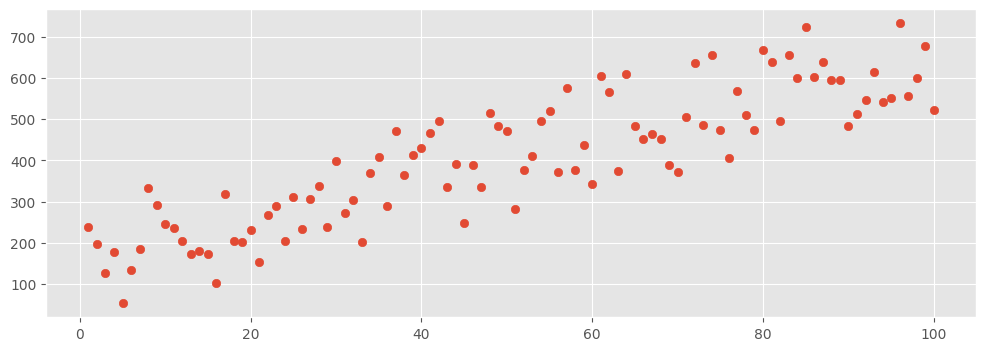

In [7]:
plt.figure(figsize=(12,4))
plt.scatter(X.reshape(100,),y.reshape(100,))
plt.show()

In [8]:
lr = LinearRegression()
lr.fit(X,y)
m = lr.coef_
b = lr.intercept_

In [9]:
lr.intercept_, lr.coef_

(array([162.07667999]), array([[4.83776087]]))

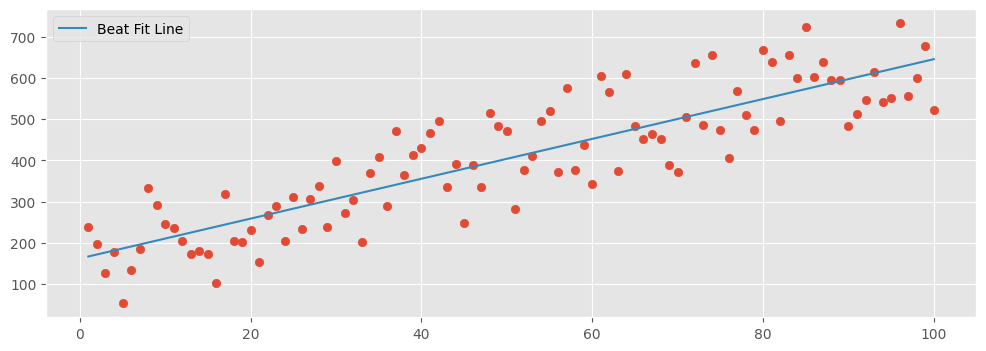

In [10]:
y_pred_actual = lr.predict(X)
plt.figure(figsize=(12,4))
plt.scatter(X.reshape(100,),y.reshape(100,))
plt.plot(X.reshape(100,),y_pred_actual,color='C1',label='Beat Fit Line')
plt.legend()
plt.show()

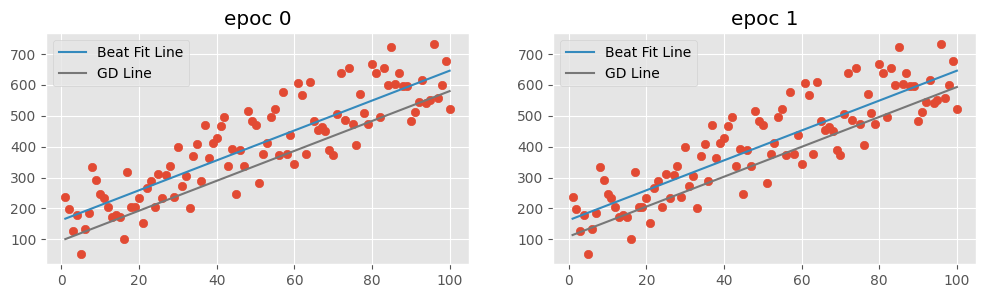

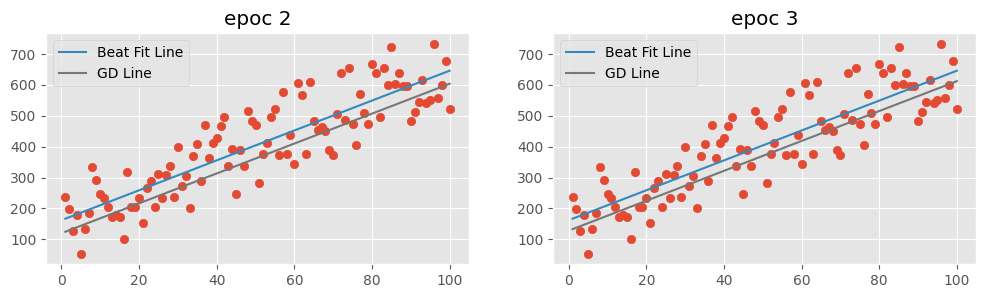

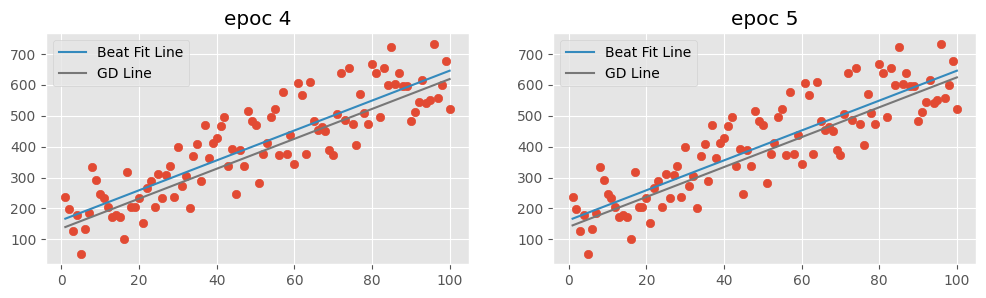

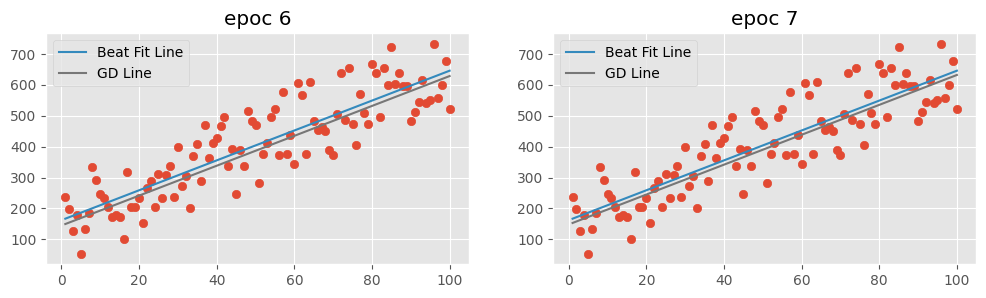

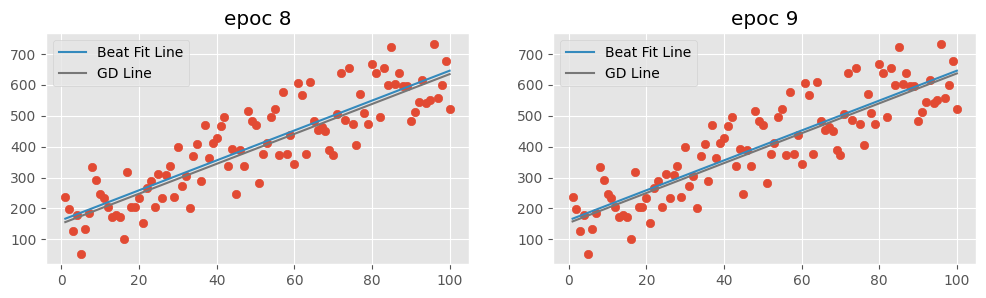

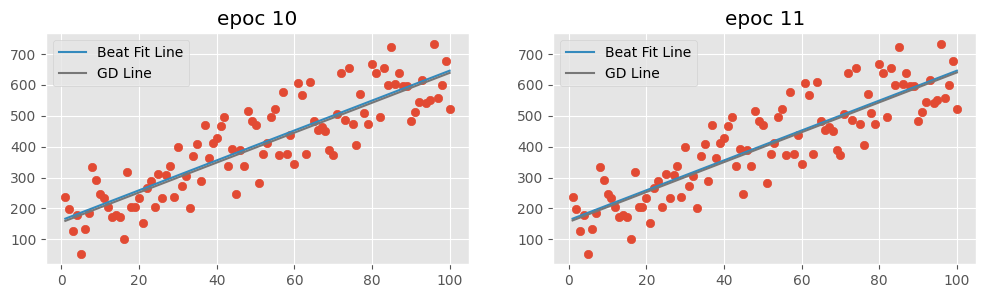

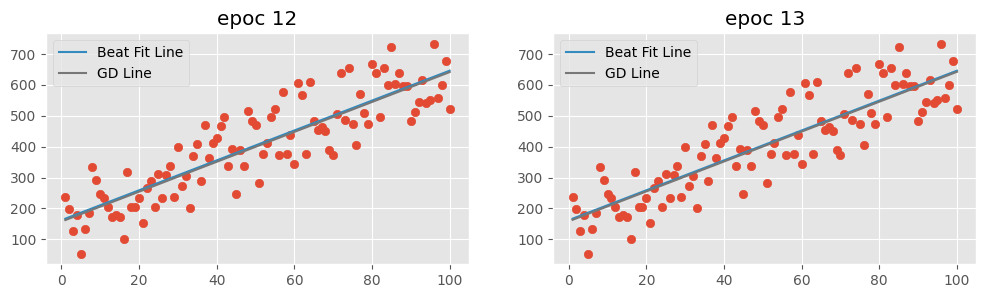

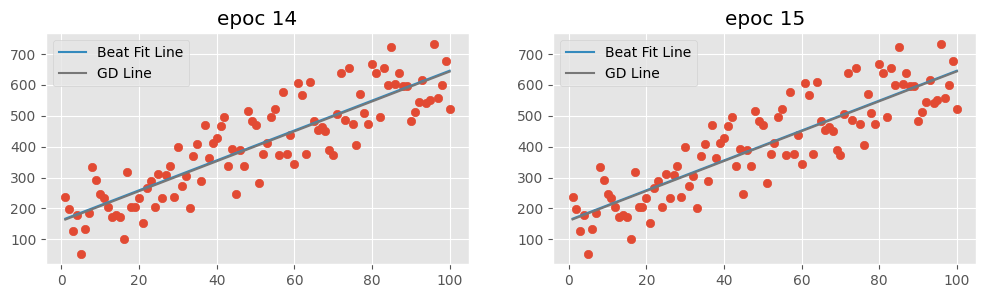

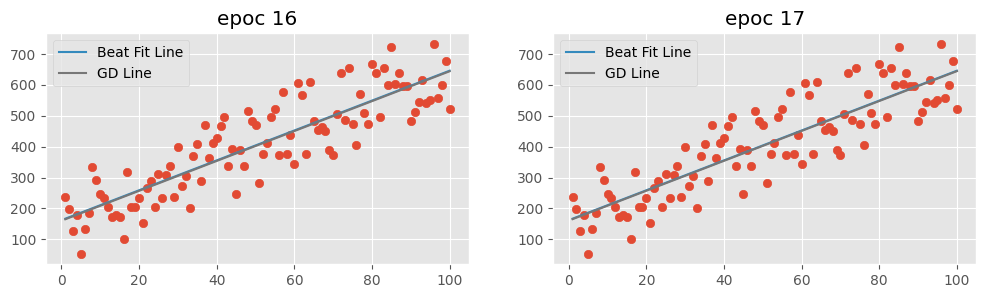

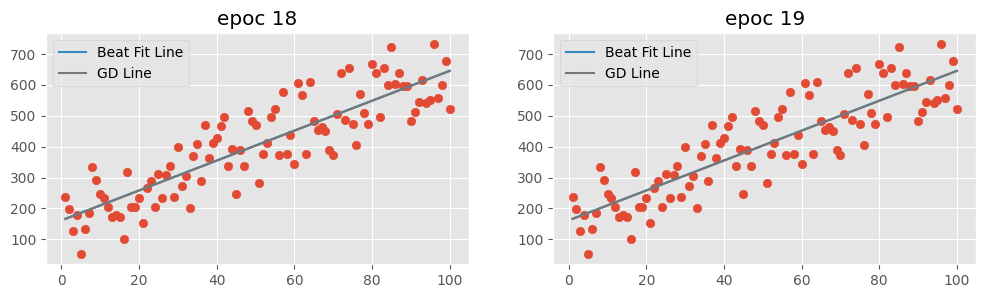

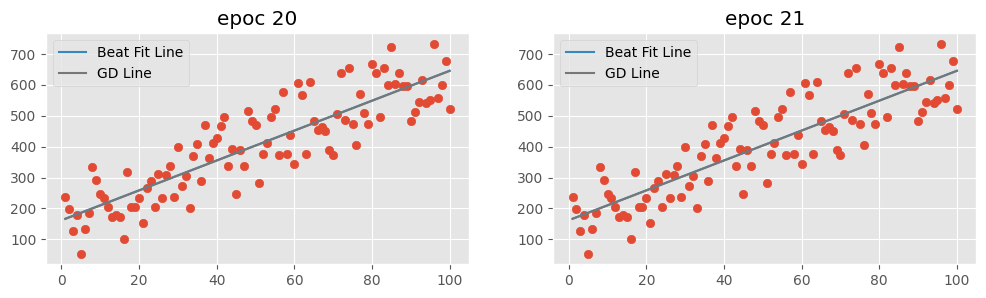

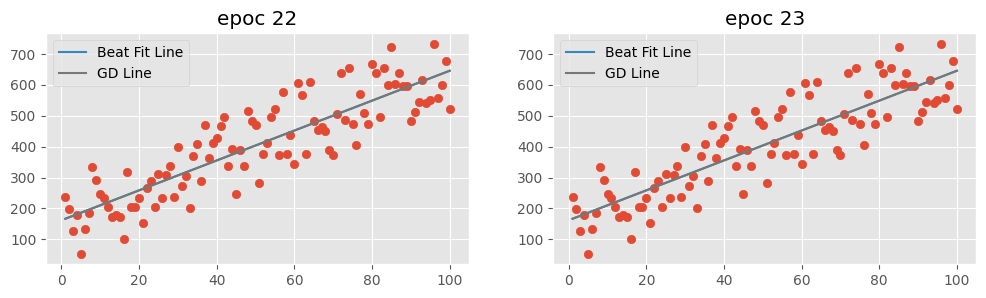

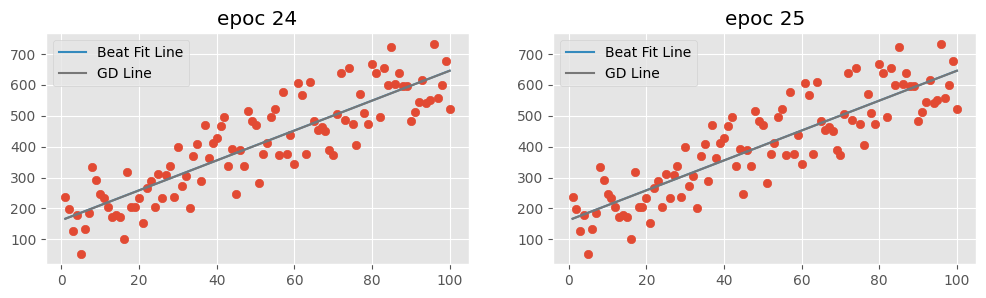

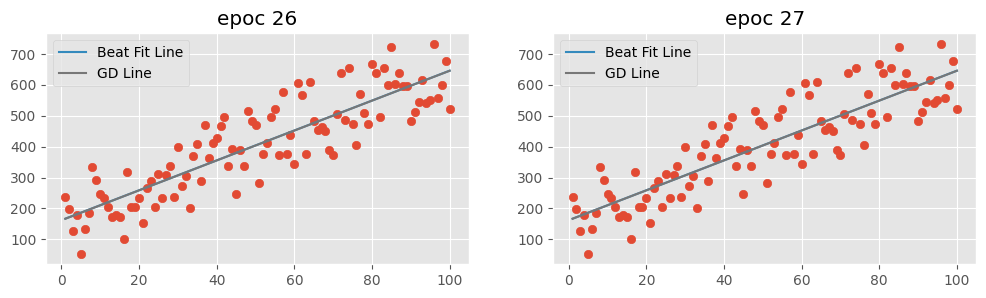

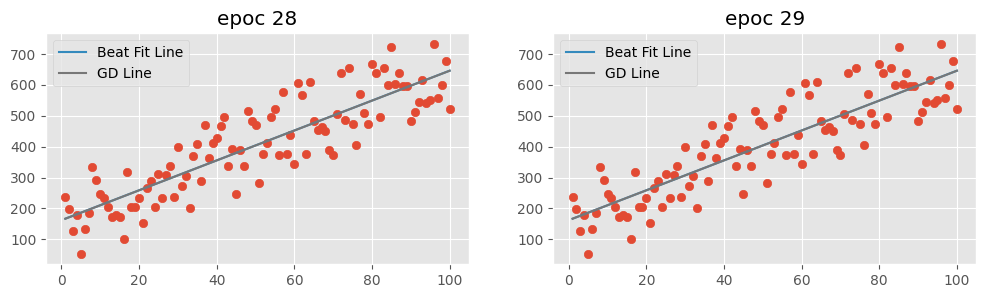

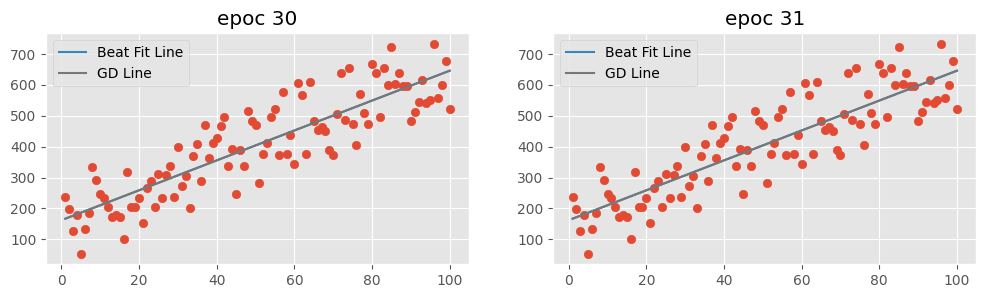

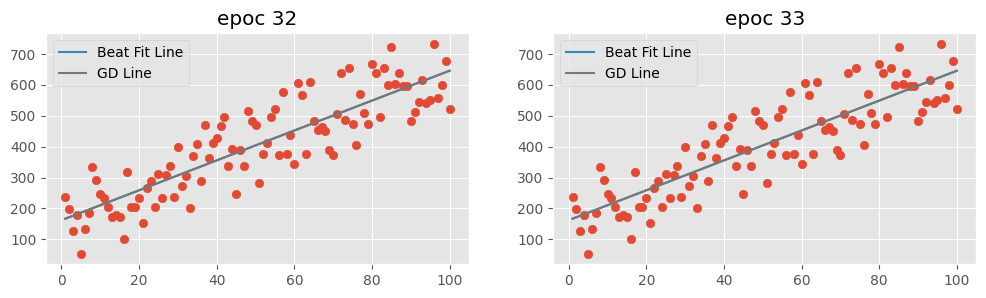

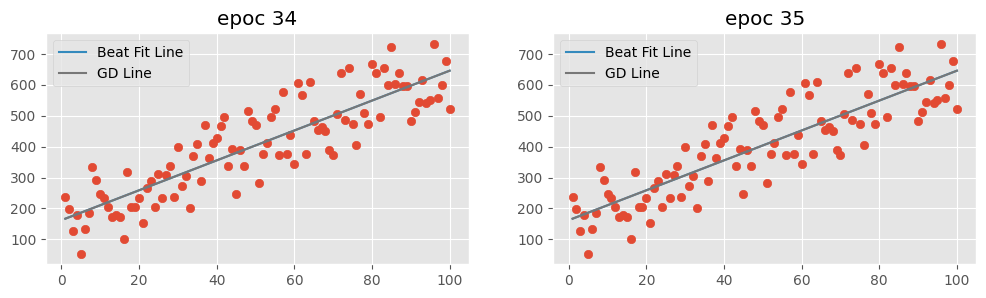

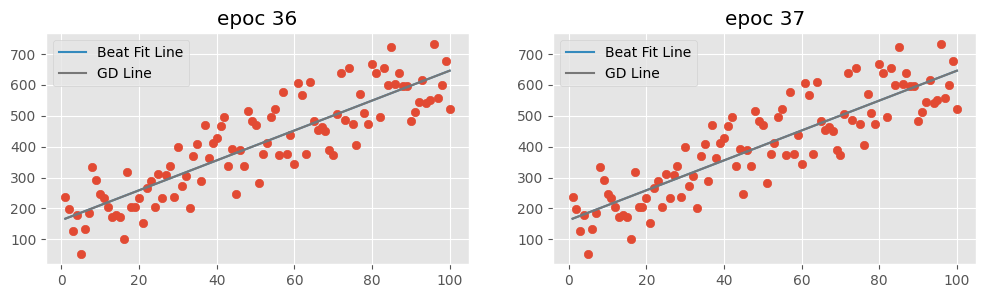

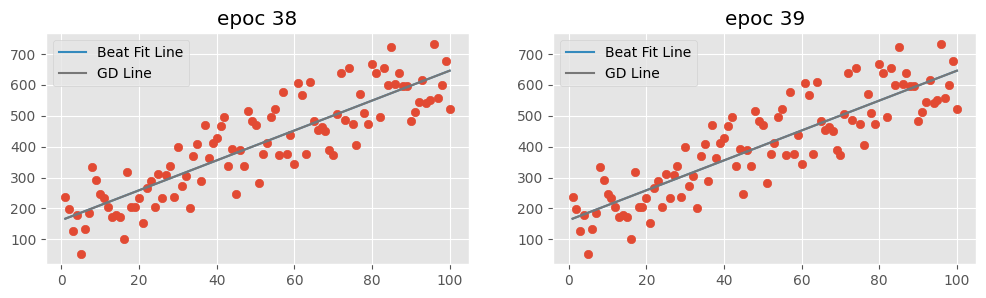

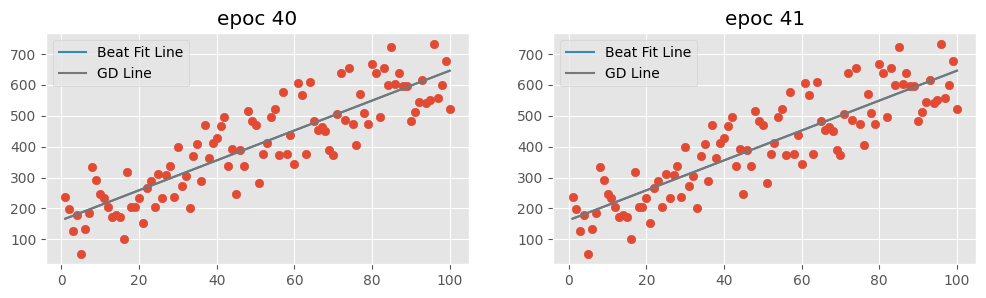

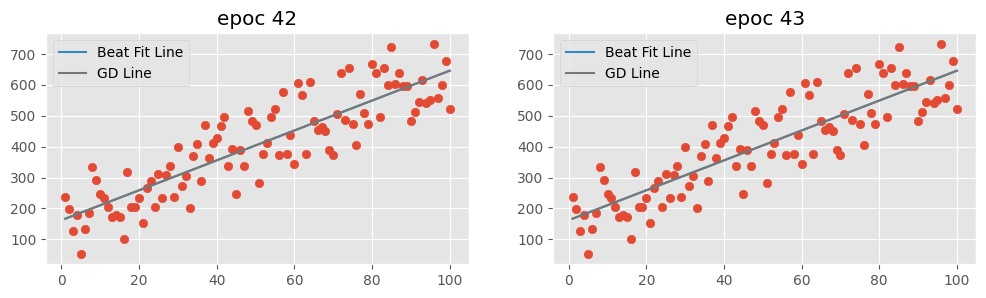

In [11]:
b_pred = np.random.randint(X.min(),X.max(),size=1)
y_pred_GD = ((m*X) + b_pred).reshape(100)
learning_rate = 0.001

plt.figure(figsize=(12,3))
i = 1
for epoc in range(100):
    plt.subplot(1,2,i)
    plt.scatter(X.reshape(100,),y.reshape(100,))
    plt.plot(X.reshape(100,),y_pred_actual,color='C1',label='Beat Fit Line')
    plt.plot(X.reshape(100,),y_pred_GD,color='C3', label='GD Line')
    plt.title(f'epoc {epoc}')
    plt.legend()
    i+=1

    slope = L_slope(X,y,m,b_pred)
    if (b_pred - (b_pred - (learning_rate*slope)) > -0.001) and (b_pred - (b_pred - (learning_rate*slope)) < 0.001):
        break
    b_pred = b_pred - (learning_rate*slope)
    y_pred_GD = ((m*X) + b_pred).reshape(100)

    if (epoc+1)%2 == 0:
        plt.show()
        plt.figure(figsize=(12,3))
        i=1
    

# Batch/Vanilla Gradiant Descent
    Calculation both coef and intercept using gradient descent

In [12]:
X, y = load_diabetes(return_X_y=True)
X.shape, y.shape

((442, 10), (442,))

In [13]:
lr = LinearRegression()
lr.fit(X,y)
lr.intercept_,lr.coef_

(np.float64(152.13348416289597),
 array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
        -792.17563855,  476.73902101,  101.04326794,  177.06323767,
         751.27369956,   67.62669218]))

In [14]:
y_pred = lr.predict(X)
r2_score(y_true=y, y_pred=y_pred)

0.5177484222203499

In [15]:
class GD_ND_Function:
    def __init__(self,epoch=100,lr=0.001):
        self.epoch = epoch
        self.lr = lr
        self.coef_ = None
        self.intercept_ = 0
    def fit(self, X, y):
        self.coef_ = np.ones(X.shape[1])
        for _ in range(self.epoch):
            y_hat = np.dot(X,self.coef_) + self.intercept_

            dif = y - y_hat
            
            intercept_drev = -2 * np.mean(dif)
            self.intercept_ = self.intercept_ - (self.lr * intercept_drev)

            coef_drev = -2 * np.dot(dif,X)/X.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_drev)
        print(self.intercept_, self.coef_)

    def predict(self, X):
        return np.dot(X,self.coef_) + self.intercept_

In [16]:
gd = GD_ND_Function(epoch=46000, lr=.01)

In [17]:
now = time()
gd.fit(X,y)
print('Time taken ', time() - now)

152.13348416289531 [   9.05929267 -189.65149572  479.67888661  298.8855912   -38.77095687
 -102.20484787 -205.875504    129.67713694  399.98297902  121.12302828]
Time taken  0.7276186943054199


In [18]:
y_pred = gd.predict(X)
r2_score(y_true=y, y_pred=y_pred)

0.5100546462325302

In [19]:
lr.coef_ - gd.coef_

array([ -19.06915897,  -50.16414795,   40.16703344,   25.4990543 ,
       -753.40468168,  578.94386888,  306.91877193,   47.38610073,
        351.29072054,  -53.49633609])

# Learning Schedules
    It employ strategies to manipulate the learning rate as the number of epochs increases.

In [20]:
t0, t1 = 5,50
def learing_rate(t):
    return t0/(t + t1)

# Stochastic Gradiant Descent
**Why Stochastic GD over Batch/Vanilla GD**
1. Derivatives are calculated for each row in every epoch.
2. y_hat = np.dot(X_train,coef_) + intercept_

        In batch/vanilla gradient descent, the entire X_train dataset is loaded into RAM for computation. If the dataset exceeds available RAM, the system may crash.

**How Stochastic GD Work**
1. Update our coefficients and intercept for each row in every epoch.

        Whereas Batch/Vanilla Gradient Descent considers the entire dataset and updates the parameters once per epoch.
2. Random selection of rows during calculation

**Limitation**
1. The output has randomness, resulting in imprecise calculations with each training run.

**Advantages**
1. It requires fewer epochs.
2. It offers faster performance with big data.

**Where To Use**
1. When dataset is to big
2. When we have Non-Convex loss function
3. Online Learning

In [21]:
X, y = load_diabetes(return_X_y=True)
X.shape, y.shape

((442, 10), (442,))

In [22]:
lr = LinearRegression()
lr.fit(X,y)
lr.intercept_,lr.coef_

(np.float64(152.13348416289597),
 array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
        -792.17563855,  476.73902101,  101.04326794,  177.06323767,
         751.27369956,   67.62669218]))

In [23]:
y_pred = lr.predict(X)
r2_score(y_true=y, y_pred=y_pred)

0.5177484222203499

In [24]:
class SGD_ND_Function:
    def __init__(self,epoch=100,lr=0.001, t0=5, t1=50, Learning_Schedules=False):
        self.Learning_Schedules = Learning_Schedules
        self.epoch = epoch
        self.lr = lr
        self.t0 = t0
        self.t1 = t1
        self.coef_ = None
        self.intercept_ = 0
    def fit(self, X, y):
        self.coef_ = np.ones(X.shape[1])
        for i in range(self.epoch):
            for j in range(X.shape[0]):
                idx = np.random.randint(0,X.shape[0],size=1)
                y_hat = np.dot(X[idx],self.coef_) + self.intercept_
    
                dif = y[idx] - y_hat

                if self.Learning_Schedules:
                    self.lr = self.learing_rate(i*X.shape[0] + j)
                
                intercept_drev = -2 * dif
                self.intercept_ = self.intercept_ - (self.lr * intercept_drev)
    
                coef_drev = -2 * np.dot(dif,X[idx])
                self.coef_ = self.coef_ - (self.lr * coef_drev)
        print(self.intercept_, self.coef_)

    def predict(self, X):
        return np.dot(X,self.coef_) + self.intercept_

    def learing_rate(self, t):
        return self.t0/(t + self.t1)

In [25]:
sgd = SGD_ND_Function(epoch=250, lr=.01, Learning_Schedules=False, t0=100, t1=1000)

In [26]:
now = time()
sgd.fit(X,y)
print('Time taken ', time() - now)

[153.77105821] [  -5.82919162 -234.40774691  533.77025681  315.10840412  -66.64332861
 -112.40312694 -208.78375223  119.97540488  458.77473154   87.26709131]
Time taken  2.0342555046081543


In [27]:
y_pred = sgd.predict(X)
r2_score(y_true=y, y_pred=y_pred)

0.5136402892525207

## Comapring Our Stochastic GD with Sk-Learn model

In [28]:
sgd = SGDRegressor(max_iter=250, learning_rate='adaptive', eta0=.01)

In [29]:
now = time()
sgd.fit(X,y)
print('Time taken ',time() - now)

Time taken  0.027614355087280273


/home/sptrop/Desktop/.desk/Jupyter/venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [30]:
y_pred = sgd.predict(X)
r2_score(y_true=y, y_pred=y_pred)

0.49620173236928367

# Mini-Batch Gradient Descent
**Why Mini-Batch GD over othe**
1. With right tuning, it takes benefits from both Stochastic GD and Batch/Vanilla GD.

**How Mini-Batch GD Work**
1. Update our coefficients and intercept for set of batchs in every epoch.

        The set of batches is determined by the batch size and the dataset size.
2. A random selection of rows within a batch is used for each calculation.

In [31]:
X, y = load_diabetes(return_X_y=True)
X.shape, y.shape

((442, 10), (442,))

In [32]:
lr = LinearRegression()
lr.fit(X,y)
lr.intercept_,lr.coef_

(np.float64(152.13348416289597),
 array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
        -792.17563855,  476.73902101,  101.04326794,  177.06323767,
         751.27369956,   67.62669218]))

In [33]:
y_pred = lr.predict(X)
r2_score(y_true=y, y_pred=y_pred)

0.5177484222203499

In [34]:
class MBGD_ND_Function:
    def __init__(self,batch_size=10,epoch=100,lr=0.001):
        self.epoch = epoch
        self.batch_size = batch_size
        self.lr = lr
        self.coef_ = None
        self.intercept_ = 0
    def fit(self, X, y):
        self.coef_ = np.ones(X.shape[1])
        for _ in range(self.epoch):
            for _ in range(int(X.shape[0]/self.batch_size)):
                idxs = np.random.choice(range(X.shape[0]),size=self.batch_size,replace=False)
                y_hat = np.dot(X[idxs],self.coef_) + self.intercept_
    
                dif = y[idxs] - y_hat
                
                intercept_drev = -2 * np.mean(dif)
                self.intercept_ = self.intercept_ - (self.lr * intercept_drev)
    
                coef_drev = -2 * np.dot(dif,X[idxs])/X[idxs].shape[0]
                self.coef_ = self.coef_ - (self.lr * coef_drev)
        print(self.intercept_, self.coef_)

    def predict(self, X):
        return np.dot(X,self.coef_) + self.intercept_

In [35]:
mbgd = MBGD_ND_Function(batch_size=int(X.shape[0]/70), epoch=450, lr=.01)

In [36]:
now = time()
mbgd.fit(X,y)
print('Time taken ', time() - now)

153.01365032688057 [  18.36564658 -151.76210709  437.11007464  281.33083832  -21.65961596
  -76.58680977 -200.59411014  135.63610988  362.63681521  133.62726038]
Time taken  2.1265156269073486


In [37]:
y_pred = mbgd.predict(X)
r2_score(y_true=y, y_pred=y_pred)

0.5020804117500535